# Dijkstra Benchmark Analysis
Comparação de desempenho entre **PairingHeap**, **BinaryHeap** e **FibonacciHeap**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ─── Carregar dados ───────────────────────────────────────────────────────────
df = pd.read_csv("../experiments/results/dijkstra_results.csv")
df.columns = df.columns.str.strip().str.replace('"', '')

# Renomear coluna com vírgula no nome
df.rename(columns={'Score Error (99,9%)': 'Score Error (99.9%)'}, inplace=True)

# Corrigir separador decimal com vírgula
df['Score'] = df['Score'].astype(str).str.replace(',', '.').astype(float)
df['Score Error (99.9%)'] = df['Score Error (99.9%)'].astype(str).str.replace(',', '.').astype(float)

# Agregar duplicatas tirando a média
df = df.groupby(
    ['Benchmark', 'Param: density', 'Param: heapType', 'Param: size'],
    as_index=False
).agg({'Score': 'mean', 'Score Error (99.9%)': 'mean'})

# Configurações compartilhadas
heaps     = ['PAIRING', 'BINARY', 'FIBONACCI']
palette   = {'PAIRING': '#E05C5C', 'BINARY': '#4A90D9', 'FIBONACCI': '#4CAF50'}
markers   = {'PAIRING': 'o',       'BINARY': 's',       'FIBONACCI': '^'}
densities = sorted(df['Param: density'].dropna().unique().astype(int))
sizes     = sorted(df['Param: size'].dropna().unique().astype(int))

def safe_err(val):
    try:
        v = float(val)
        return 0 if np.isnan(v) else v
    except (ValueError, TypeError):
        return 0

def plot_metric(benchmark_name, label, filename_prefix):
    """Gera um gráfico por tamanho de grafo.
    Eixo X = densidades | Linhas = tipo de heap."""
    for size in sizes:
        subset = df[
            (df['Benchmark'] == benchmark_name) &
            (df['Param: size'] == size)
        ].copy()
        subset['Param: density'] = subset['Param: density'].astype(int)

        fig, ax = plt.subplots(figsize=(9, 5))
        fig.suptitle(
            f'Dijkstra Benchmark — {label} ({size} vértices)',
            fontsize=13, fontweight='bold'
        )

        for heap in heaps:
            vals, errs = [], []
            for d in densities:
                row = subset[
                    (subset['Param: heapType'] == heap) &
                    (subset['Param: density'] == d)
                ]
                vals.append(float(row['Score'].values[0]) if len(row) else np.nan)
                errs.append(safe_err(row['Score Error (99.9%)'].values[0]) if len(row) else 0)

            vals = np.array(vals)
            errs = np.array(errs)
            cor  = palette[heap]

            ax.plot(densities, vals, color=cor, marker=markers[heap],
                    linewidth=2, markersize=7, label=heap, zorder=3)

            mask = errs > 0
            if mask.any():
                ax.fill_between(
                    np.array(densities)[mask],
                    (vals - errs)[mask],
                    (vals + errs)[mask],
                    color=cor, alpha=0.12, zorder=2
                )

            # rótulo no último ponto válido
            last_idx = np.where(~np.isnan(vals))[0]
            if len(last_idx):
                i = last_idx[-1]
                ax.annotate(
                    f'{vals[i]:.3g}',
                    xy=(densities[i], vals[i]),
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=8, color=cor, va='center'
                )

        ax.set_xticks(densities)
        ax.set_xticklabels([f'{d}%' for d in densities])
        ax.set_xlabel('Densidade (%)', fontsize=10)
        ax.set_ylabel(label, fontsize=10)
        ax.legend(fontsize=9)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(
            lambda v, _: f'{v:,.0f}' if v >= 1000 else f'{v:.3g}'))
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.grid(axis='x', linestyle='--', alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)

        plt.tight_layout()
        filename = f'{filename_prefix}_{size}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f'Gráfico salvo em {filename}')
        plt.show()

print(f'Setup concluído!')
print(f'Tamanhos  : {sizes}')
print(f'Densidades: {densities}')


Setup concluído!
Tamanhos  : [np.int64(100), np.int64(500), np.int64(1000)]
Densidades: [np.int64(10), np.int64(30), np.int64(50), np.int64(70), np.int64(90)]


## 1. Tempo de execução (ms/op)

Gráfico salvo em chart_tempo_100.png


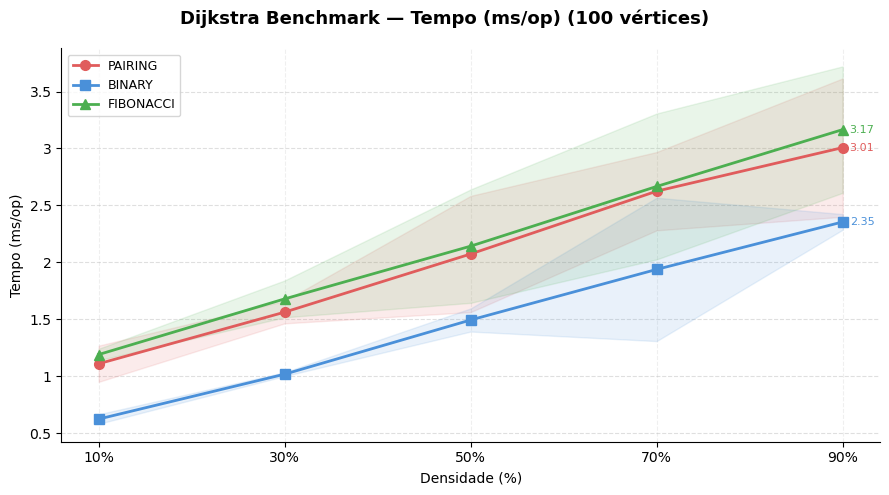

Gráfico salvo em chart_tempo_500.png


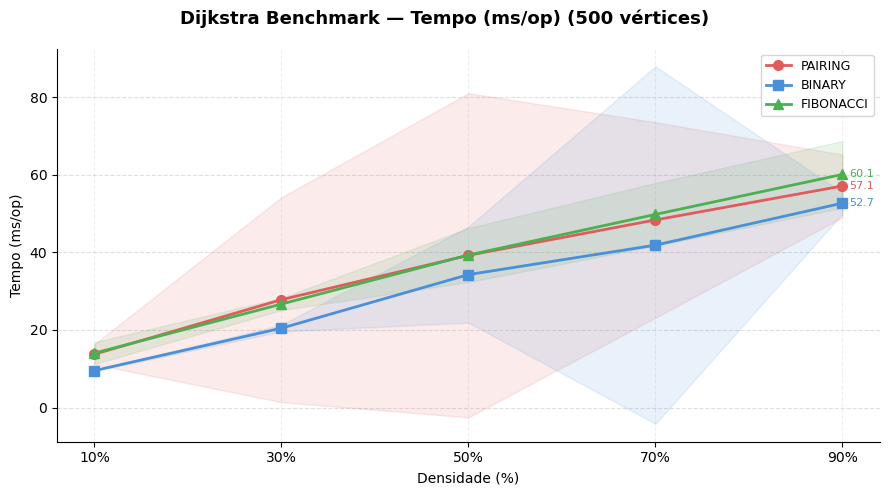

Gráfico salvo em chart_tempo_1000.png


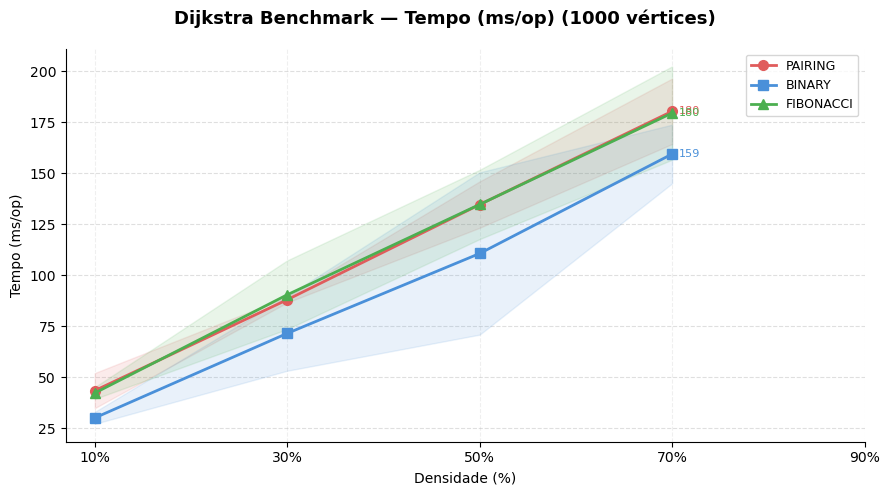

In [2]:
plot_metric(
    'benchmarks.DijkstraBenchmark.runDijkstra',
    'Tempo (ms/op)',
    'chart_tempo'
)

## 2. Alocação de memória por operação (B/op)

Gráfico salvo em chart_alocacao_100.png


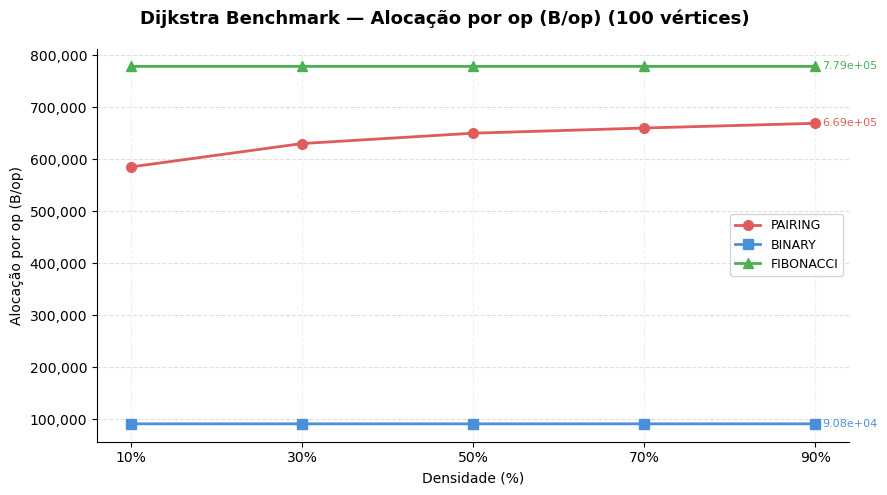

Gráfico salvo em chart_alocacao_500.png


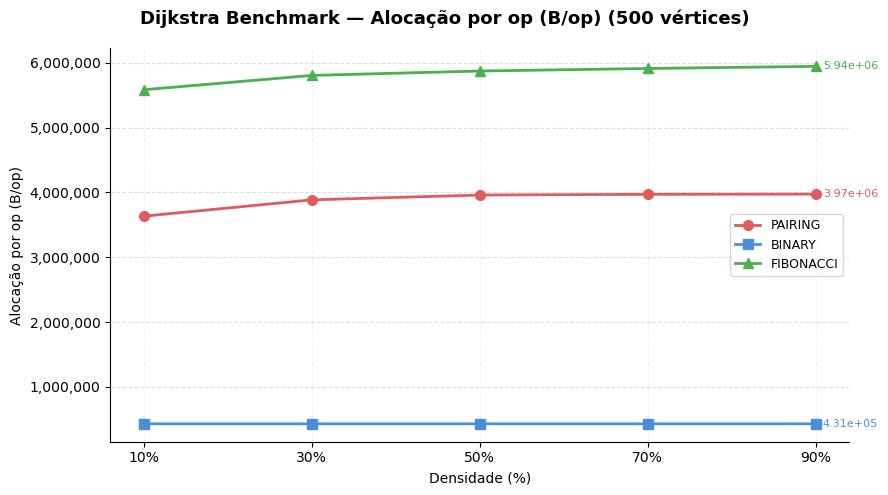

Gráfico salvo em chart_alocacao_1000.png


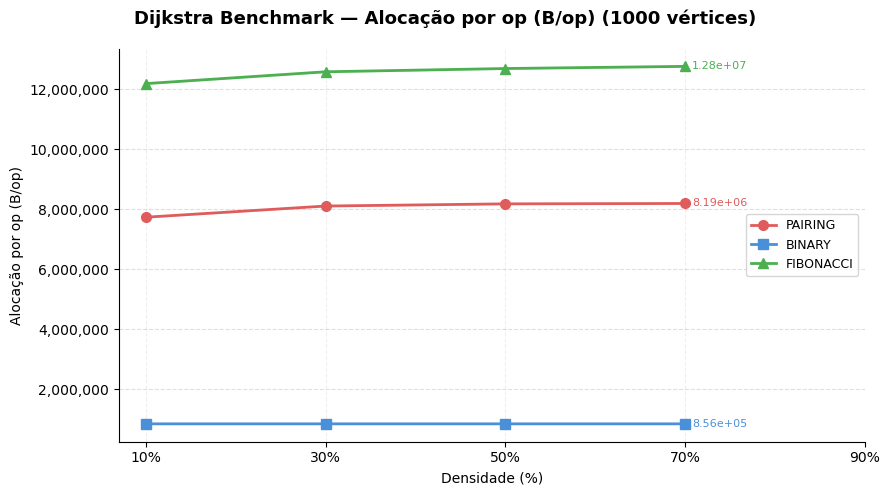

In [3]:
plot_metric(
    'benchmarks.DijkstraBenchmark.runDijkstra:gc.alloc.rate.norm',
    'Alocação por op (B/op)',
    'chart_alocacao'
)

## 3. Coletas de Garbage Collection (count)

Gráfico salvo em chart_gc_count_100.png


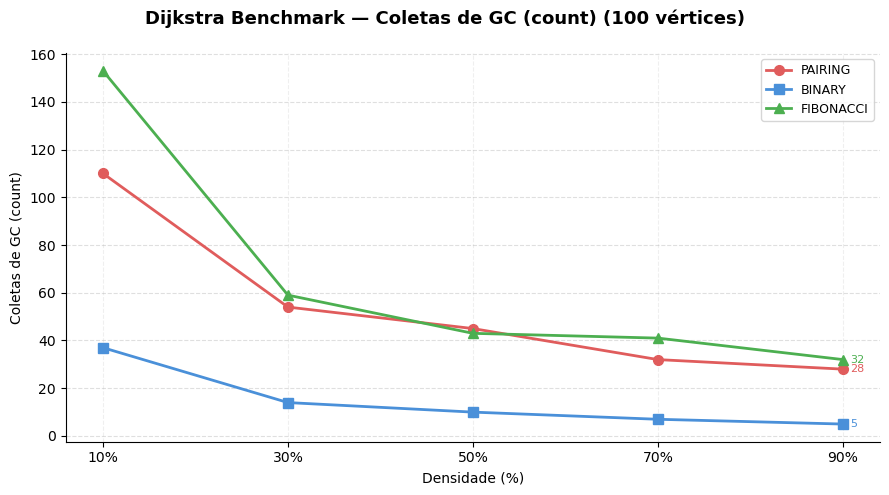

Gráfico salvo em chart_gc_count_500.png


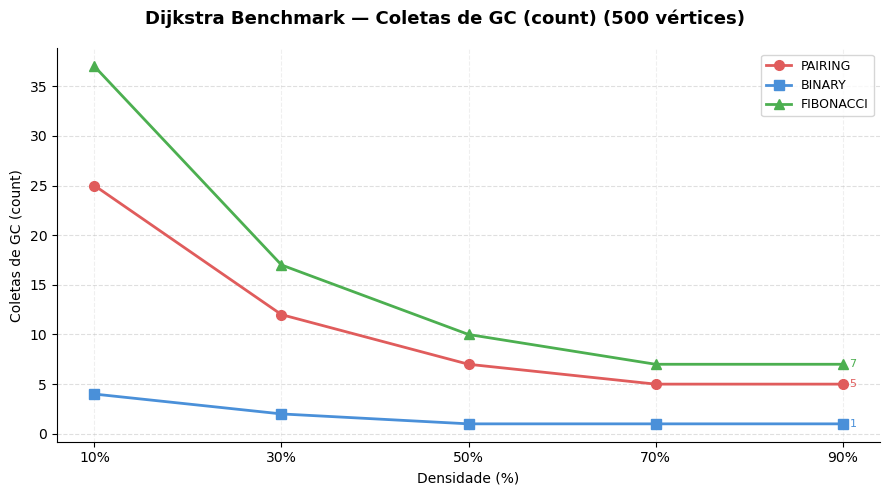

Gráfico salvo em chart_gc_count_1000.png


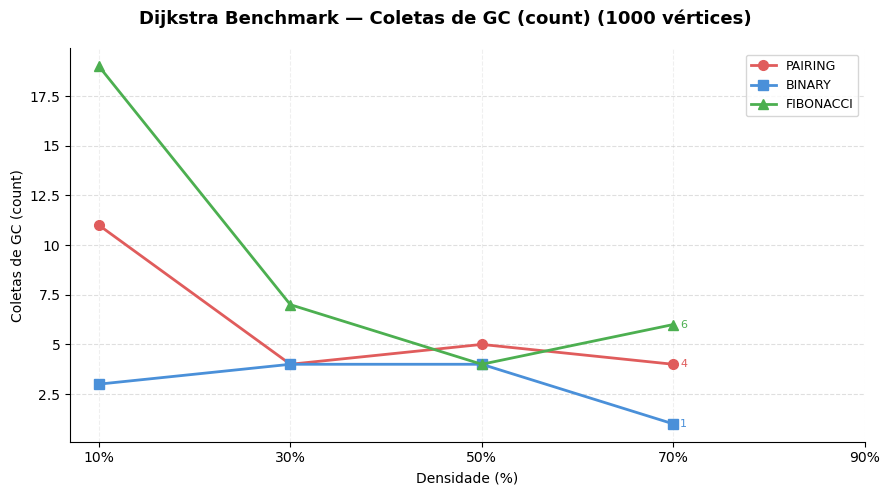

In [4]:
plot_metric(
    'benchmarks.DijkstraBenchmark.runDijkstra:gc.count',
    'Coletas de GC (count)',
    'chart_gc_count'
)

## 4. Tempo Gasto em Garbage Collection (ms)

Gráfico salvo em chart_gc_time_100.png


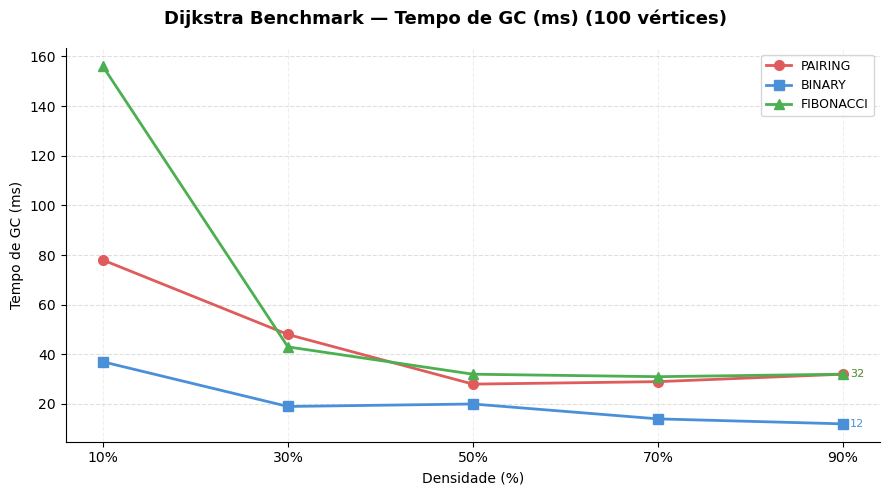

Gráfico salvo em chart_gc_time_500.png


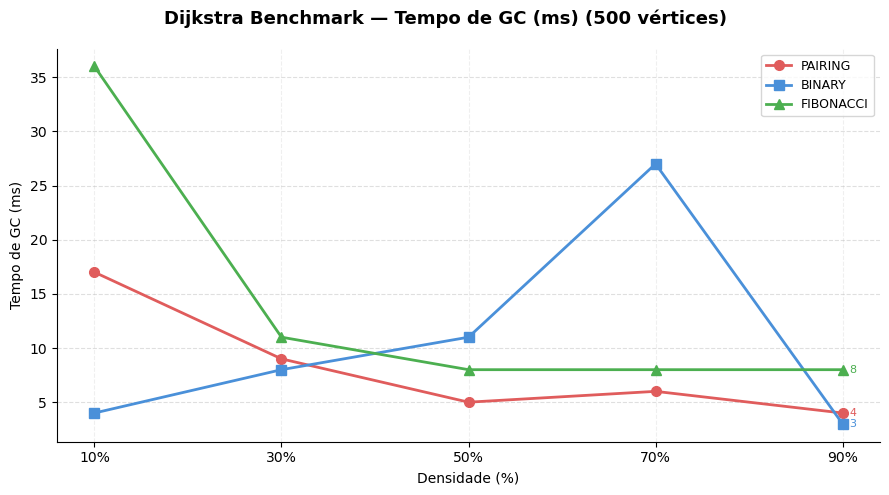

Gráfico salvo em chart_gc_time_1000.png


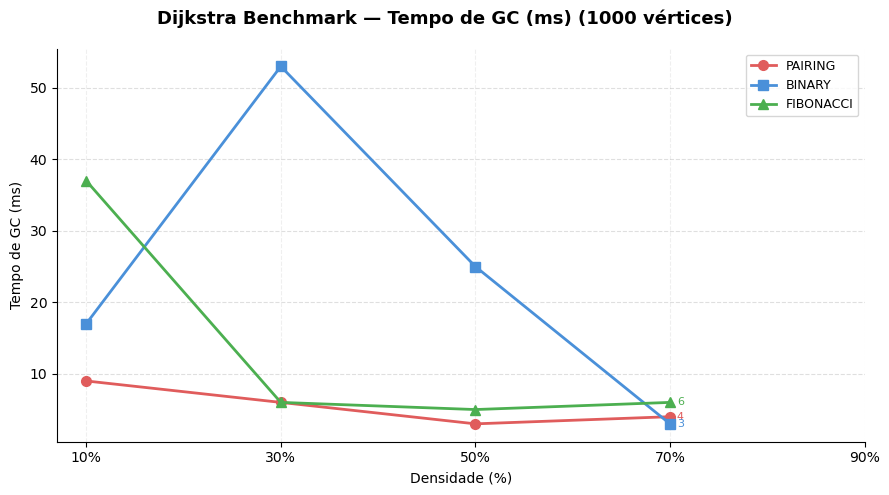

In [5]:
plot_metric(
    'benchmarks.DijkstraBenchmark.runDijkstra:gc.time',
    'Tempo de GC (ms)',
    'chart_gc_time'
)

## 5. Decrease Keys (count) 

In [6]:
"""plot_metric(
    'benchmarks.DijkstraBenchmark.runDijkstra:decreaseKeys',
    'Decrease Keys (count)',
    'chart_decrease_keys'
) """

"plot_metric(\n    'benchmarks.DijkstraBenchmark.runDijkstra:decreaseKeys',\n    'Decrease Keys (count)',\n    'chart_decrease_keys'\n) "